# Lab 23 — Turbo Codes, EXIT Charts and Density Evolution

**Companion to Chapter 15** (*Turbo, LDPC and Polar Codes*). Lab 9 covers LDPC and polar codes; this lab is
the turbo half of the chapter and the analysis tools that explain all iterative decoders.
**Time needed:** about 2 hours. **Difficulty:** advanced.

In 1993 Berrou, Glavieux and Thitimajshima showed a code within about half a decibel of the Shannon limit, and the
audience assumed a mistake. The trick was two simple recursive convolutional codes, an interleaver, and a decoder that
lets two soft-in/soft-out BCJR decoders argue until they agree. Eight years later ten Brink's EXIT chart explained
*why* it works, and *where* the threshold is, with one picture; density evolution did the same for LDPC codes and
predicted, exactly, the thresholds that spatially coupled codes later reached. This lab builds the LTE turbo code with
`commlib/turbo.py` (the same module that drew Chapter 15's figures), checks the decoder against brute force, watches it
iterate, finds its error floor, and then draws EXIT charts and runs density evolution on the erasure channel.

### What you will learn
1. Build the 8-state (13, 15) recursive systematic code and the LTE QPP interleaver, and see why recursion matters.
2. Verify that the BCJR algorithm computes exact a-posteriori probabilities, and what max-log-MAP gives up.
3. Measure the BER of an iterative turbo decoder iteration by iteration, near the Shannon limit.
4. Predict the error floor from the low-weight codewords produced by weight-2 inputs.
5. Measure EXIT curves and a real decoding trajectory, and find the tunnel-opening threshold.
6. Run density evolution on the BEC for regular, irregular and spatially coupled LDPC ensembles.

### Prerequisites
Lab 8 (convolutional codes, Viterbi), Lab 9 (LDPC). LLRs (Chapter 9), mutual information (Chapter 13). Chapter 15.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | The RSC constituent code and the QPP interleaver | |
| 2 | BCJR against brute force; log-MAP vs max-log-MAP | |
| 3 | Iterative decoding: BER iteration by iteration | yes |
| 4 | The error floor and weight-2 codewords | |
| 5 | EXIT charts and the decoding trajectory | yes |
| 6 | Density evolution on the BEC: regular, irregular, coupled | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import commlib as cl
from commlib import turbo as tb
from commlib import infotheory as it
from commlib import labkit as lk

rng = lk.setup(seed=23, lab="23")
QPP = {40: (3, 10), 256: (15, 32), 1024: (31, 64), 6144: (263, 480)}   # TS 36.212 Table 5.1.3-3 entries


def sigma_of(ebn0_db, R):
    """Noise standard deviation for BPSK at Eb/N0 (dB) and code rate R."""
    return np.sqrt(1 / (2 * R * lk.undb(ebn0_db)))


def awgn_llr(bits, ebn0_db, R, rng):
    s = sigma_of(ebn0_db, R)
    return 2 * ((1 - 2.0 * bits) + s * rng.standard_normal(np.shape(bits))) / s ** 2


def bpsk_limit_db(R):
    """Smallest Eb/N0 (dB) at which the BPSK-input AWGN channel supports rate R."""
    es = brentq(lambda e: it.biawgn_capacity(e) - R, 1e-4, 50)
    return 10 * np.log10(es / R)

Lab 23 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 23


## 1. The RSC constituent code and the QPP interleaver

Each constituent encoder of the UMTS/LTE turbo code (3GPP TS 36.212 §5.1.3) is an 8-state **recursive systematic
convolutional** (RSC) code with feedback $g_0 = 1 + D^2 + D^3$ (13 octal) and feed-forward $g_1 = 1 + D + D^3$
(15 octal). *Recursive* is the key word: a single 1 at the input never returns the register to zero, so it produces an
infinitely long, periodic parity sequence. Only inputs whose polynomial is divisible by the feedback polynomial
terminate; the lightest are **weight-2 inputs** with the two ones a multiple of 7 apart (the period of $1+D^2+D^3$,
a primitive polynomial of degree 3). The interleaver's job is to make sure that a weight-2 pattern that is short for
encoder 1 is long for encoder 2.

LTE uses a **quadratic permutation polynomial** (QPP) interleaver, $\pi(i) = (f_1 i + f_2 i^2) \bmod K$, contention-free
for parallel decoders. Chapter 15's worked example takes $K = 40$, $(f_1, f_2) = (3, 10)$.

state,a(k-1..k-3),next (u=0),parity (u=0),next (u=1),parity (u=1)
0,000,0,0,4,1
1,001,4,0,0,1
2,010,5,1,1,0
3,011,1,1,5,0
4,100,2,1,6,0
5,101,6,1,2,0
6,110,7,0,3,1
7,111,3,0,7,1


"K = 40, (f1, f2) = (3, 10)",
pi(0..9),0 13 6 19 12 25 18 31 24 37
steps pi(i+1)-pi(i) mod 40,13 33 13 33 13 33 13 33 13
is a permutation,True


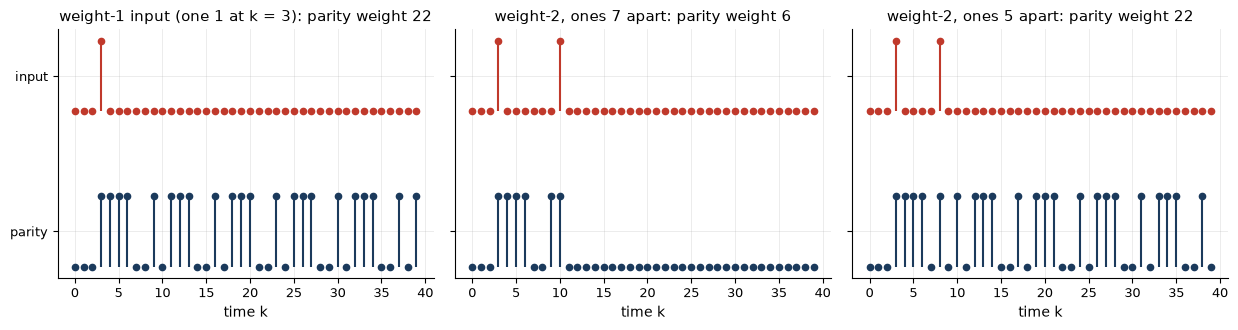

In [3]:
rsc = tb.RSC()
rows = [[s, f"{s:03b}", rsc.next_state[s, 0], rsc.parity[s, 0], rsc.next_state[s, 1], rsc.parity[s, 1]] for s in range(8)]
lk.table(rows, ["state", "a(k-1..k-3)", "next (u=0)", "parity (u=0)", "next (u=1)", "parity (u=1)"],
         title="(13, 15) RSC trellis, the LTE constituent code")
pi40 = tb.qpp_interleaver(40, *QPP[40])
lk.table([["pi(0..9)", " ".join(str(v) for v in pi40[:10])],
          ["steps pi(i+1)-pi(i) mod 40", " ".join(str(v) for v in np.diff(pi40[:10]) % 40)],
          ["is a permutation", len(set(pi40)) == 40]], ["K = 40, (f1, f2) = (3, 10)", ""])

T = 40
u1 = np.zeros((1, T), int); u1[0, 3] = 1                    # weight-1 input
u2 = np.zeros((1, T), int); u2[0, [3, 10]] = 1              # weight-2, separation 7
u3 = np.zeros((1, T), int); u3[0, [3, 8]] = 1               # weight-2, separation 5
f, ax = lk.fig((12.5, 3.4), 1, 3, sharey=True)
for a, (uu, lab) in zip(ax, [(u1, "weight-1 input (one 1 at k = 3)"), (u2, "weight-2, ones 7 apart"), (u3, "weight-2, ones 5 apart")]):
    _, p = rsc.encode(uu, terminate=False)
    a.stem(np.arange(T), uu[0] + 2.2, linefmt="C1-", markerfmt="C1o", basefmt=" ", bottom=2.2)
    a.stem(np.arange(T), p[0], linefmt="C0-", markerfmt="C0o", basefmt=" ")
    a.set_title(f"{lab}: parity weight {p[0].sum()}"); a.set_xlabel("time k"); a.set_yticks([0.5, 2.7])
    a.set_yticklabels(["parity", "input"])
lk.show(f)

**What you should see.** The QPP interleaver for $K=40$ starts $0, 13, 6, 19, 12, 25, \ldots$ and its steps alternate
$13, 33, 13, 33$, exactly as in the chapter's worked example. A single input 1 makes parity forever (weight grows with the
block length); two ones 7 apart make a short burst of parity and the encoder returns to state 0; two ones 5 apart do not
terminate. Low-weight turbo codewords therefore need a weight-2 input that is a multiple-of-7 pattern for *both*
encoders, which a good interleaver makes rare.

### Try it yourself 1.1
What is $\pi(7)$ for the LTE interleaver with $K = 40$? (Do it by hand with the recursion, then check.)

In [5]:
answer_1_1 = None
lk.check("1.1 pi(7) for K = 40", answer_1_1, int(pi40[7]), atol=0)

[TODO] 1.1 pi(7) for K = 40: not attempted yet: replace the None with your answer

## 2. BCJR against brute force; log-MAP vs max-log-MAP

The BCJR algorithm computes $L(u_k) = \ln \frac{P(u_k=0\mid\mathbf y)}{P(u_k=1\mid\mathbf y)}$ with a forward
recursion $\alpha$, a backward recursion $\beta$ and branch metrics $\gamma$, in time linear in the block length. On a
short block we can check it against the definition: enumerate all $2^K$ inputs, weight each codeword by
$\exp\big(\tfrac12\sum_i L_i x_i\big)$ and sum. **Log-MAP** uses the exact Jacobian logarithm
$\max^*(a,b) = \max(a,b) + \ln(1+e^{-|a-b|})$ and should agree to rounding error; **max-log-MAP** drops the correction
term (it becomes a soft-output Viterbi with the same hard decisions as ML sequence detection) and overestimates
reliabilities.

In [7]:
Kb = 6
ub = rng.integers(0, 2, (1, Kb))
sb, pb = rsc.encode(ub)                                     # terminated: 6 + 3 trellis steps
s_ = sigma_of(1.0, 0.5)
Ls_ = 2 * ((1 - 2.0 * sb) + s_ * rng.standard_normal(sb.shape)) / s_ ** 2
Lp_ = 2 * ((1 - 2.0 * pb) + s_ * rng.standard_normal(pb.shape)) / s_ ** 2
L_logmap = tb.bcjr(rsc, Ls_, Lp_)[0, :Kb]
L_maxlog = tb.bcjr(rsc, Ls_, Lp_, maxlog=True)[0, :Kb]
allu = np.array(list(itertools.product([0, 1], repeat=Kb)))
cs, cp = rsc.encode(allu)
metric = 0.5 * ((1 - 2.0 * cs) @ Ls_[0] + (1 - 2.0 * cp) @ Lp_[0])
L_brute = np.array([np.logaddexp.reduce(metric[allu[:, k] == 0]) - np.logaddexp.reduce(metric[allu[:, k] == 1]) for k in range(Kb)])
lk.table([[k, int(ub[0, k]), L_brute[k], L_logmap[k], L_maxlog[k]] for k in range(Kb)],
         ["k", "sent bit", "brute force (2^6 words)", "BCJR log-MAP", "BCJR max-log-MAP"], fmt=".4f")
lk.note(f"largest |log-MAP - brute force| = {np.max(np.abs(L_logmap - L_brute)):.2e}")

k,sent bit,brute force (2^6 words),BCJR log-MAP,BCJR max-log-MAP
0,0,-1.4911,-1.4911,-1.4952
1,1,-6.1804,-6.1804,-6.0938
2,0,-1.5041,-1.5041,-1.4952
3,1,1.4542,1.4542,1.4952
4,0,6.6693,6.6693,6.5136
5,0,5.4707,5.4707,5.2810


[info] largest |log-MAP - brute force| = 3.55e-15

**What you should see.** Log-MAP equals brute force to about $10^{-12}$: BCJR is an exact computation, just organised on
the trellis. Max-log-MAP has the same signs but larger magnitudes, and that overconfidence is what costs it a few tenths of
a dB inside a turbo decoder (Section 3), where wrong reliabilities are fed back as a-priori information.

### Try it yourself 2.1
How many terms would the brute-force sum need for the LTE block length $K = 6144$? Give $\log_{10}$ of that number.

In [9]:
answer_2_1 = None
lk.check("2.1 log10(2^6144)", answer_2_1, 6144 * np.log10(2), atol=1)

[TODO] 2.1 log10(2^6144): not attempted yet: replace the None with your answer

## 3. Iterative decoding: BER iteration by iteration

The turbo decoder runs BCJR on encoder 1, subtracts what it was told to obtain **extrinsic** LLRs
$L_{E1} = L_{\text{APP}} - L^x_{\text{ch}} - L_{A1}$, interleaves them into decoder 2 as a-priori information, and back
again. Chapter 15's Figure 15-*turbo-iters* uses the LTE $K = 1024$ code (rate $1024/3084 \approx 1/3$). Its BPSK Shannon
limit is about $-0.5$ dB. Max-log-MAP is cheaper but loses a few tenths of a dB; scaling its extrinsic output by about 0.7
recovers most of the loss (the correction every LTE modem uses).

### Interactive: block length, decoder and iterations
Monte Carlo sizes are small so that the panel runs in about 20 s; raise `frames` for smoother curves.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

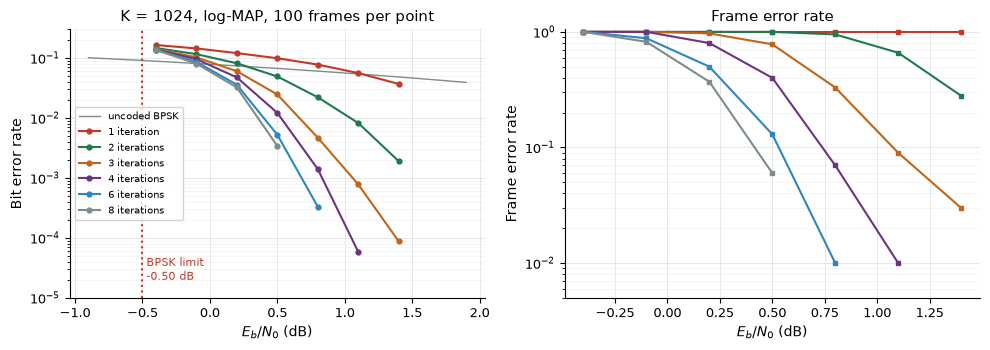

Eb/N0 (dB),"BER, 1 it.","BER, 2 it.","BER, 8 it."
-0.4,1.6e-01,1.5e-01,1.4e-01
-0.1,1.4e-01,1.2e-01,8.1e-02
+0.2,1.2e-01,8.2e-02,3.2e-02
+0.5,9.9e-02,4.9e-02,3.4e-03
+0.8,7.8e-02,2.2e-02,0.0e+00
+1.1,5.6e-02,8.3e-03,0.0e+00
+1.4,3.7e-02,1.9e-03,0.0e+00


In [11]:
def turbo_ber(tc, ebs, iters, maxlog=False, scale=1.0, frames=100, B=50, seed=0):
    r = np.random.default_rng(seed)
    ber = np.zeros((iters, len(ebs))); fer = np.zeros_like(ber)
    for j, e in enumerate(ebs):
        for _ in range(frames // B):
            u = r.integers(0, 2, (B, tc.K))
            hist = tc.decode(awgn_llr(tc.flatten(tc.encode(u)), e, tc.rate, r), iters=iters, record=True, maxlog=maxlog, scale=scale)
            for i, h in enumerate(hist):
                ne = (h != u).sum(axis=1); ber[i, j] += ne.sum(); fer[i, j] += (ne > 0).sum()
        ber[:, j] /= frames * tc.K; fer[:, j] /= frames
    return ber, fer


def iter_demo(K=1024, decoder="log-MAP", iters=8, frames=100):
    tc = tb.TurboCode(K, tb.qpp_interleaver(K, *QPP[K]))
    ebs = np.arange(-0.4, 1.41, 0.3) if K >= 1024 else np.arange(0, 3.01, 0.5)
    ml, sc = {"log-MAP": (False, 1.0), "max-log-MAP": (True, 1.0), "max-log-MAP, scaled 0.7": (True, 0.7)}[decoder]
    ber, fer = turbo_ber(tc, ebs, iters, ml, sc, frames=frames, seed=K)
    lim = bpsk_limit_db(tc.rate)
    f, ax = lk.fig("row2", 1, 2)
    ebf = np.linspace(ebs[0] - 0.5, ebs[-1] + 0.5, 100)
    ax[0].semilogy(ebf, cl.ber_bpsk(ebf), color=lk.GRAY, lw=1, label="uncoded BPSK")
    show = sorted(set([0, 1, 2, 3, 5, iters - 1]) & set(range(iters)))
    for c, i in enumerate(show):
        b = np.where(ber[i] > 0, ber[i], np.nan)
        ax[0].semilogy(ebs, b, "o-", ms=3.5, color=lk.PALETTE[c + 1], label=f"{i + 1} iteration{'s' if i else ''}")
    ax[0].axvline(lim, color=lk.RED, ls=":"); ax[0].text(lim + 0.03, 2e-5, f"BPSK limit\n{lim:.2f} dB", color=lk.RED, fontsize=8)
    lk.ber_axes(ax[0], ylim=(1e-5, 0.3)); ax[0].legend(fontsize=7.5); ax[0].set_title(f"K = {K}, {decoder}, {frames} frames per point")
    for c, i in enumerate(show):
        ax[1].semilogy(ebs, np.where(fer[i] > 0, fer[i], np.nan), "s-", ms=3.5, color=lk.PALETTE[c + 1], label=f"{i + 1} it.")
    lk.ber_axes(ax[1], ylabel="Frame error rate", ylim=(5e-3, 1.05)); ax[1].set_title("Frame error rate")
    lk.show(f)
    lk.table([[f"{e:+.1f}"] + [f"{ber[i, j]:.1e}" for i in (0, 1, iters - 1)] for j, e in enumerate(ebs)],
             ["Eb/N0 (dB)", "BER, 1 it.", "BER, 2 it.", f"BER, {iters} it."])

lk.interact(iter_demo, K=lk.choice([40, 256, 1024], 1024, "block length K"),
            decoder=lk.choice(["log-MAP", "max-log-MAP", "max-log-MAP, scaled 0.7"], "log-MAP", "decoder"),
            iters=lk.islider(8, 2, 12, 1, "iterations"), frames=lk.choice([100, 200, 500, 1000], 100, "frames per point"))

**What you should see.** One iteration is little better than a single convolutional code. Each further iteration moves the
waterfall left, with diminishing returns after about six: at 0.8 dB the BER falls from about $8\times10^{-2}$ after one iteration to
$2\times10^{-2}$ after two and to zero errors in 100 frames after eight, about 1.3 dB from the $-0.5$ dB limit at this short length. With
$K = 40$ (the smallest LTE block) the interleaver has no room to work and the curve moves right by more than a decibel: turbo
gain grows with block length. Switch to max-log-MAP to see its loss, and to the scaled version to see most of it come back.

Now compare the three decoders directly at a fixed SNR, where the differences are clearest.

In [13]:
tc1024 = tb.TurboCode(1024, tb.qpp_interleaver(1024, *QPP[1024]))
rows = []
for name, ml, sc in [("log-MAP", False, 1.0), ("max-log-MAP", True, 1.0), ("max-log-MAP, extrinsic x 0.7", True, 0.7)]:
    b, fr = turbo_ber(tc1024, [0.8], 8, ml, sc, frames=100, seed=99)
    rows.append([name, f"{b[-1, 0]:.2e}", f"{fr[-1, 0]:.3f}"])
lk.table(rows, ["decoder (8 iterations)", "BER at 0.8 dB", "FER at 0.8 dB"], title="K = 1024 LTE turbo code")

decoder (8 iterations),BER at 0.8 dB,FER at 0.8 dB
log-MAP,0.00e+00,0.000
max-log-MAP,1.28e-02,0.150
"max-log-MAP, extrinsic x 0.7",2.05e-04,0.020


### Try it yourself 3.1
The LTE code with $K = 1024$ sends $3K + 12$ bits (the 12 are tail bits of both encoders). What is its exact rate?

In [15]:
answer_3_1 = None
lk.check("3.1 rate of the K = 1024 LTE turbo code", answer_3_1, 1024 / 3084, atol=1e-4)

[TODO] 3.1 rate of the K = 1024 LTE turbo code: not attempted yet: replace the None with your answer

## 4. The error floor and weight-2 codewords

Below the waterfall a turbo code's BER flattens into an **error floor**, set by a few low-weight codewords. With recursive
constituents, the dominant ones come from weight-2 inputs whose ones are $7m$ apart for encoder 1 *and* whose interleaved
images are also a multiple of 7 apart for encoder 2. Their union-bound contribution is
$P_b \approx \sum_d \frac{w}{K}\, Q\big(\sqrt{2 R d\, E_b/N_0}\big)$ with $w = 2$ information errors per codeword.
Chapter 15's worked example: two codewords of weight 14 at $K = 1024$, $R = 1/3$, 2 dB, give a floor of about $2.3\times 10^{-7}$.
Below we enumerate every weight-2 input with a separation of up to 56 in either encoder's input order and encode it,
for the QPP interleaver and for a random one.

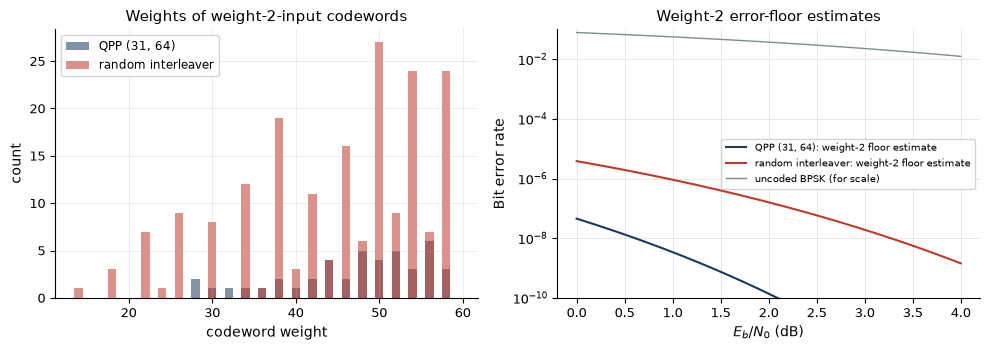

interleaver,minimum weight found,number at that weight,floor estimate at 2 dB
"QPP (31, 64)",28,2,1.4e-10
random interleaver,14,1,1.6e-07


,P_b
Chapter 15 worked example: 2 words of weight 14 at 2 dB,2.34e-07


In [17]:
def weight2_codewords(tc, dmax_sep=56):
    """Total weights of the codewords generated by weight-2 inputs that are short in either encoder."""
    K, pi = tc.K, tc.pi
    pairs = set()
    for d in range(7, dmax_sep + 1, 7):
        for i in range(K - d):
            pairs.add((i, i + d))
            a, b = pi[i], pi[i + d]
            pairs.add((min(a, b), max(a, b)))
    pairs = np.array(sorted(pairs))
    u = np.zeros((len(pairs), K), np.int8)
    u[np.arange(len(pairs)), pairs[:, 0]] = 1; u[np.arange(len(pairs)), pairs[:, 1]] = 1
    return np.concatenate([tc.flatten(tc.encode(u[s:s + 4000])).sum(axis=1) for s in range(0, len(u), 4000)])


codes = [("QPP (31, 64)", tc1024, lk.NAVY), ("random interleaver", tb.TurboCode(1024, np.random.default_rng(5).permutation(1024)), lk.RED)]
ebf = np.linspace(0, 4, 200)
f, ax = lk.fig("row2", 1, 2)
rows = []
for name, tc, col in codes:
    w = weight2_codewords(tc)
    dmin = int(w.min())
    ax[0].hist(w, bins=np.arange(dmin - 0.5, 60.5), color=col, alpha=0.55, label=name)
    low = w[w <= dmin + 6]
    floor = sum((2 / tc.K) * cl.qfunc(np.sqrt(2 * tc.rate * d * lk.undb(ebf))) for d in low)
    ax[1].semilogy(ebf, floor, color=col, label=f"{name}: weight-2 floor estimate")
    rows.append([name, dmin, int(np.sum(w == dmin)), f"{np.interp(2.0, ebf, floor):.1e}"])
ax[1].semilogy(ebf, cl.ber_bpsk(ebf), color=lk.GRAY, lw=1, label="uncoded BPSK (for scale)")
ax[0].set_xlabel("codeword weight"); ax[0].set_ylabel("count"); ax[0].legend(); ax[0].set_title("Weights of weight-2-input codewords")
lk.ber_axes(ax[1], ylim=(1e-10, 0.1)); ax[1].legend(fontsize=7.5); ax[1].set_title("Weight-2 error-floor estimates")
lk.show(f)
lk.table(rows, ["interleaver", "minimum weight found", "number at that weight", "floor estimate at 2 dB"])
d14 = 2 * (2 / 1024) * cl.qfunc(np.sqrt(2 / 3 * 14 * lk.undb(2.0)))
lk.table([["Chapter 15 worked example: 2 words of weight 14 at 2 dB", f"{d14:.2e}"]], ["", "P_b"])

**What you should see.** The random interleaver lets through a few low-weight codewords, and its floor sits an order of
magnitude or more above the QPP interleaver's, which is designed to spread weight-2 patterns. Both floors fall slowly
(roughly a factor of 4–5 per dB) while the waterfall falls by orders of magnitude per dB: the shape of every turbo BER curve.
The worked example evaluates to $2.3\times10^{-7}$. The QPP floor is far below anything Monte Carlo can reach in a lab,
which is why floors are predicted from weight spectra, not simulated.

### Try it yourself 4.1
Using the same formula, estimate the floor at 3 dB for two weight-14 codewords (it should fall by only about 5×).

In [19]:
answer_4_1 = None
lk.check("4.1 floor at 3 dB, two words of weight 14", answer_4_1, 2 * (2 / 1024) * cl.qfunc(np.sqrt(2 / 3 * 14 * lk.undb(3.0))), rtol=0.05)

[TODO] 4.1 floor at 3 dB, two words of weight 14: not attempted yet: replace the None with your answer

## 5. EXIT charts and the decoding trajectory

Model the a-priori LLRs entering a constituent decoder as consistent Gaussian, $L_A = \tfrac{\sigma_A^2}{2}x + \mathcal N(0,
\sigma_A^2)$; their mutual information with the bits is $I_A = J(\sigma_A)$. Feed a decoder synthetic $L_A$ with a chosen
$I_A$, measure the mutual information $I_E$ of its extrinsic output, and you have its **transfer curve** $I_E = T(I_A)$.
Plot decoder 1's curve and decoder 2's with the axes swapped: iterative decoding is a staircase between them, and it
reaches $(1,1)$ only if the **tunnel** between the curves is open. The SNR at which the tunnel just opens is the
**threshold** of the code (for long blocks); Chapter 15 finds it at about $-0.1$ dB for the rate-1/3 LTE code, about 0.4 dB from the limit.

### Interactive: channel SNR

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

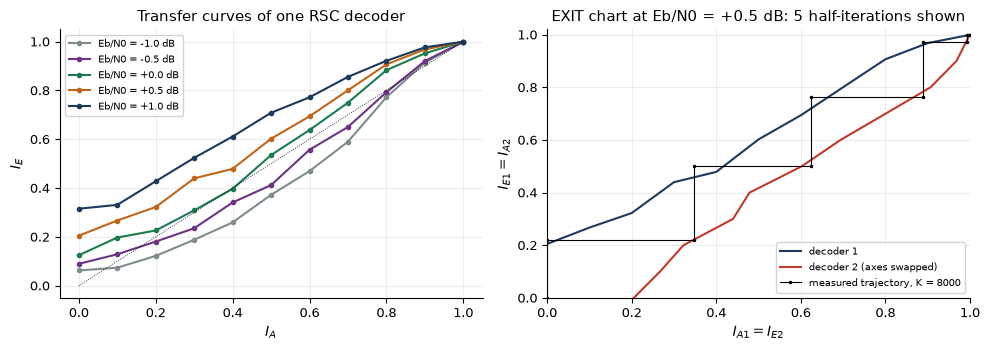

In [21]:
IA_grid = np.linspace(0, 1, 11)
exit_cache = {}

def exit_curve(eb):
    if eb not in exit_cache:
        exit_cache[eb] = tb.exit_curve_rsc(rsc, sigma_of(eb, 1 / 3), IA_grid, K=2000, reps=10, rng=np.random.default_rng(int(10 * eb) + 50))
    return exit_cache[eb]

def exit_demo(ebn0=0.5):
    f, ax = lk.fig("row2", 1, 2)
    for eb, col in [(-1.0, lk.GRAY), (-0.5, lk.PURPLE), (0.0, lk.GREEN), (0.5, lk.ORANGE), (1.0, lk.NAVY)]:
        ax[0].plot(IA_grid, exit_curve(eb), "o-", ms=3, color=col, label=f"Eb/N0 = {eb:+.1f} dB")
    ax[0].plot([0, 1], [0, 1], "k:", lw=0.6)
    ax[0].set_xlabel("$I_A$"); ax[0].set_ylabel("$I_E$"); ax[0].legend(fontsize=7.5); ax[0].set_title("Transfer curves of one RSC decoder")
    IE = exit_curve(ebn0)
    ax[1].plot(IA_grid, IE, color=lk.NAVY, label="decoder 1")
    ax[1].plot(IE, IA_grid, color=lk.RED, label="decoder 2 (axes swapped)")
    Kt = 8000
    tc = tb.TurboCode(Kt, np.random.default_rng(9).permutation(Kt))
    r = np.random.default_rng(4)
    u = r.integers(0, 2, (2, Kt))
    _, traj = tc.decode(awgn_llr(tc.flatten(tc.encode(u)), ebn0, tc.rate, r), iters=12, Linfo=u)
    X, Y = [0.0], [0.0]
    for j, (ia, ie) in enumerate(traj):
        if j % 2 == 0:
            X.append(X[-1]); Y.append(ie)
        else:
            X.append(ie); Y.append(Y[-1])
        if ie > 0.999:
            break
    ax[1].plot(X, Y, "k.-", lw=0.8, ms=3, label=f"measured trajectory, K = {Kt}")
    ax[1].set_xlim(0, 1); ax[1].set_ylim(0, 1.02); ax[1].set_xlabel("$I_{A1} = I_{E2}$"); ax[1].set_ylabel("$I_{E1} = I_{A2}$")
    ax[1].legend(fontsize=7.5, loc="lower right"); ax[1].set_title(f"EXIT chart at Eb/N0 = {ebn0:+.1f} dB: {len(X) // 2} half-iterations shown")
    lk.show(f)

lk.interact(exit_demo, ebn0=lk.choice([-1.0, -0.5, 0.0, 0.5, 1.0], 0.5, "Eb/N0 (dB)"))

**What you should see.** Every transfer curve starts above zero at $I_A = 0$ (the decoder learns something from the channel
alone) and rises to 1. At $+0.5$ dB the two curves leave a narrow tunnel and the measured trajectory, from a real decoder on
an 8000-bit block, climbs through it in a staircase that hugs the predicted curves until it reaches the top corner. At
$-0.5$ dB the curves cross and the trajectory stalls at the crossing: that is the waterfall's left edge, read off a
picture without a single BER simulation. Near the threshold the steps get tiny, which is why decoding near the limit needs
many iterations.

### Try it yourself 5.1
Using the transfer curve at $+0.5$ dB, what extrinsic information does decoder 1 produce from the channel alone ($I_A = 0$)?
(Read `exit_curve(0.5)[0]`; the check accepts ±0.02.)

In [23]:
answer_5_1 = None
lk.check("5.1 I_E(0) at +0.5 dB", answer_5_1, float(exit_curve(0.5)[0]), atol=0.02)

[TODO] 5.1 I_E(0) at +0.5 dB: not attempted yet: replace the None with your answer

## 6. Density evolution on the BEC: regular, irregular, coupled

On the binary erasure channel the messages of belief propagation are either known or erased, so density evolution
collapses to one number per iteration: the erasure probability $x_\ell$ of variable-to-check messages,
$$x_{\ell+1} = \varepsilon\,\lambda\big(1 - \rho(1 - x_\ell)\big),$$
with edge-perspective degree polynomials $\lambda$, $\rho$. Decoding succeeds iff $x_\ell \to 0$, i.e. iff
$\varepsilon\lambda(1-\rho(1-x)) < x$ for all $x \in (0, \varepsilon]$. For the $(3,6)$ ensemble the threshold is
$\varepsilon^* = 0.4294$ against a capacity limit of 0.5 (Chapter 15's worked example). A **spatially coupled** chain of
$L$ such codes, with a known boundary, decodes as a *wave* that travels inwards, and its BP threshold rises to the
ensemble's MAP threshold 0.4881: threshold saturation (Kudekar, Richardson and Urbanke, 2011).

### Interactive: erasure probability

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

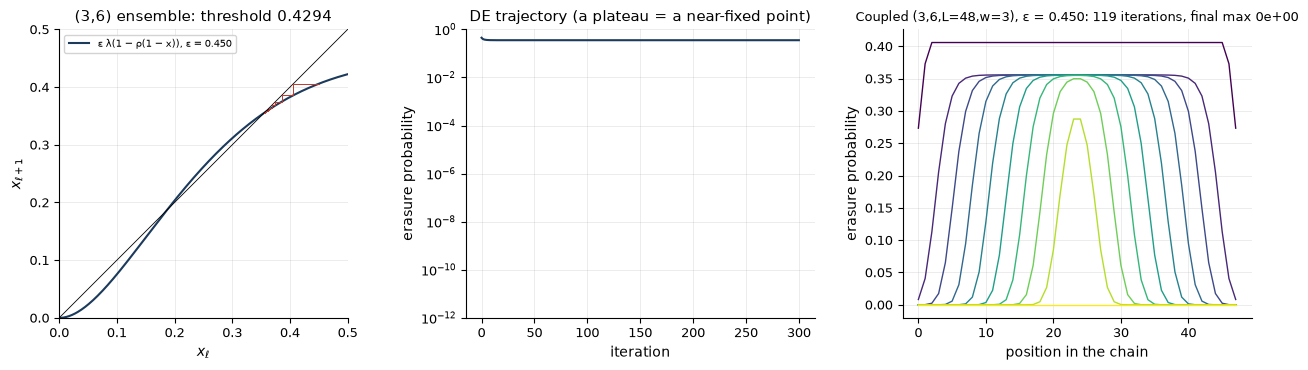

"(3,6) regular",
design rate,0.5000
BP threshold ε*,0.4294
capacity limit 1 − R,0.5000
fraction of capacity,0.8589


In [25]:
def de_demo(eps=0.45, ensemble="(3,6) regular"):
    lam, rho = {"(3,6) regular": ([0, 0, 1], [0, 0, 0, 0, 0, 1]), "(4,8) regular": ([0, 0, 0, 1], [0] * 7 + [1]),
                "irregular λ = 0.3x + 0.3x² + 0.4x⁷, ρ = x⁶": ([0, 0.3, 0.3, 0, 0, 0, 0, 0.4], [0] * 6 + [1])}[ensemble]
    lf = lambda x: sum(c * x ** i for i, c in enumerate(lam))
    rf = lambda x: sum(c * x ** i for i, c in enumerate(rho))
    thr = tb.bec_threshold(lam, rho)
    rate = 1 - sum(c / (i + 1) for i, c in enumerate(rho)) / sum(c / (i + 1) for i, c in enumerate(lam))
    xs = np.linspace(0, 0.5, 400)
    f, ax = lk.fig((13, 3.8), 1, 3)
    ax[0].plot(xs, eps * lf(1 - rf(1 - xs)), color=lk.NAVY, label=f"ε λ(1 − ρ(1 − x)), ε = {eps:.3f}")
    ax[0].plot(xs, xs, "k", lw=0.6)
    x = eps; X, Y = [x], [0.0]; traj = [x]
    for _ in range(300):
        fx = eps * lf(1 - rf(1 - x)); X += [x, fx]; Y += [fx, fx]; x = fx; traj.append(x)
    ax[0].plot(X[1:], Y[1:], color=lk.RED, lw=0.7)
    ax[0].set_xlim(0, 0.5); ax[0].set_ylim(0, 0.5); ax[0].set_aspect("equal"); ax[0].legend(fontsize=7.5, loc="upper left")
    ax[0].set_xlabel("$x_\\ell$"); ax[0].set_ylabel("$x_{\\ell+1}$"); ax[0].set_title(f"{ensemble.split(' ')[0]} ensemble: threshold {thr:.4f}")
    ax[1].semilogy(np.maximum(traj, 1e-16), color=lk.NAVY); ax[1].set_ylim(1e-12, 1)
    ax[1].set_xlabel("iteration"); ax[1].set_ylabel("erasure probability"); ax[1].set_title("DE trajectory (a plateau = a near-fixed point)")
    L = 48
    prof, snaps = tb.de_bec_coupled(eps, 3, 6, L, w=3, iters=4000, record_every=1)
    cm = plt.get_cmap("viridis")
    sh = [snaps[i] for i in np.linspace(0, len(snaps) - 1, 10).astype(int)]
    for i, s in enumerate(sh):
        ax[2].plot(s, color=cm(i / max(1, len(sh) - 1)), lw=1)
    ax[2].set_xlabel("position in the chain"); ax[2].set_ylabel("erasure probability")
    ax[2].set_title(f"Coupled (3,6,L={L},w=3), ε = {eps:.3f}: {len(snaps)} iterations, final max {prof.max():.0e}", fontsize=9)
    lk.show(f)
    lk.table([["design rate", rate], ["BP threshold ε*", thr], ["capacity limit 1 − R", 1 - rate], ["fraction of capacity", thr / (1 - rate)]],
             [ensemble, ""], fmt=".4f")

lk.interact(de_demo, eps=lk.slider(0.45, 0.30, 0.50, 0.005, "erasure probability ε"),
            ensemble=lk.choice(["(3,6) regular", "(4,8) regular", "irregular λ = 0.3x + 0.3x² + 0.4x⁷, ρ = x⁶"], "(3,6) regular", "ensemble"))

**What you should see.** At the default $\varepsilon = 0.45$, above the $(3,6)$ threshold of 0.4294, the DE curve crosses the
diagonal: the staircase stops at a non-zero fixed point (about 0.36) and the trajectory flattens there for ever. Slide ε to
0.42, just below threshold: the curve barely clears the diagonal near $x \approx 0.26$, the staircase squeezes through a
narrow gap, and the trajectory shows a long plateau before it falls. The $(4,8)$ ensemble, same rate, has a lower threshold
(0.3834). The irregular ensemble of Chapter 15's worked example has rate 0.524. The coupled chain at 0.45, where the
uncoupled code is stuck, still decodes: the known boundary lets the ends decode first, and two waves travel inwards
(dark to light) until the whole chain is clean.

The cell below finds the coupled threshold for several chain lengths by bisection.

In [27]:
rows = []
for Lc in (8, 16, 32):
    lo, hi = 0.40, 0.90
    for _ in range(14):
        mid = 0.5 * (lo + hi)
        p = tb.de_bec_coupled(mid, 3, 6, Lc, w=3, iters=6000, tol=1e-12)
        lo, hi = (mid, hi) if p.max() < 1e-8 else (lo, mid)
    RL = 0.5 - 0.5 * (3 + 1 - 2 * sum((i / 3) ** 6 for i in range(4))) / Lc        # rate loss of the terminated chain
    rows.append([Lc, lo, 1 - RL])
lk.table(rows, ["chain length L", "coupled BP threshold", "capacity limit 1 − R_L"], fmt=".4f",
         title="(3,6,L,3) coupled ensembles: uncoupled BP 0.4294, MAP 0.4881")

chain length L,coupled BP threshold,capacity limit 1 − R_L
8,0.5019,0.6139
16,0.4882,0.5569
32,0.4877,0.5285


**What you should see.** Short chains have a large rate loss (the termination costs rate) and a high threshold; as $L$
grows the threshold falls towards 0.4881, the MAP threshold of the underlying $(3,6)$ ensemble, well above the uncoupled
BP threshold of 0.4294, while the rate loss vanishes as $1/L$.

### Try it yourself 6.1
Find the BEC threshold of the $(3,6)$ ensemble yourself by minimising $x / (1-(1-x)^5)^2$ over $x \in (0, 1]$.

In [29]:
answer_6_1 = None
lk.check("6.1 BEC threshold of (3,6)", answer_6_1, 0.42944, atol=5e-4)

[TODO] 6.1 BEC threshold of (3,6): not attempted yet: replace the None with your answer

## Key takeaways
* A turbo code is two recursive convolutional codes and an interleaver; recursion makes weight-1 inputs produce heavy
  codewords, and the interleaver makes short weight-2 patterns rare in both encoders.
* BCJR computes exact APPs on the trellis; max-log-MAP is cheaper, overconfident, and fixed largely by scaling extrinsics by about 0.7.
* Iterations move the waterfall towards the Shannon limit with diminishing returns; longer blocks get closer.
* The error floor is set by a handful of low-weight codewords and falls only about 5× per dB: predict it, do not simulate it.
* EXIT charts turn iterative decoding into a staircase between two curves: an open tunnel means convergence.
* Density evolution on the BEC gives exact thresholds ((3,6): 0.4294); spatial coupling saturates BP to the MAP threshold.

## Going further (hardware: USRP B200 / GNU Radio)
* Replace the K = 7 convolutional code in `gnuradio/gr05_coded_link.py` with `commlib.turbo.TurboCode(1024, ...)` (decode in
  the Python sink) and compare the over-the-air BER at an SNR 2 dB lower.
* Capture an LTE downlink and decode its PBCH (a tail-biting convolutional code); the PDSCH turbo code needs the full rate
  matcher of TS 36.212 §5.1.4, a good project.

## Exercises
1. **(Warm-up)** Verify the QPP permutation condition for $K = 6144$, $(f_1, f_2) = (263, 480)$, by factorising $K$.
2. **(Core)** Add early stopping (stop when the hard decisions do not change between iterations) and plot the average number
   of iterations against $E_b/N_0$.
3. **(Core)** Puncture to rate 1/2 (`TurboCode(..., puncture=True)`), redraw the EXIT chart and find the new threshold.
4. **(Stretch)** Implement Gaussian-approximation density evolution for the $(3,6)$ ensemble on the AWGN channel using `tb.J`
   and compare with Chapter 15's threshold of about 1.1 dB.

In [31]:
lk.summary()

[good] Lab 23 finished in 57.8 s. Self-checks: 0 passed, 0 failed, 6 still to do.